### What is MLP?
- MLP consists of fully connected dense layers that transform input data from one dimension to another dimension.
- It is called multi-layer because it contains an input layer, one or more hidden layers and an output layer.
- The purpose of MLP is to model complex relationships between inputs and outputs.
### Working of MLP:
- The key mechanisms such as forward propagation, loss function, backpropagation and optimization.
#### 1. Forward Propagation:
- In forward propagation the data flows from the input layer to the output layers, passing through any hidden layers.
- Each neuron in the hidden layers processes the input as follows:
  1. Weighted Sum: The neuron computes the weighted sum of the inputs.
     - z = ∑iw(i)x(i) + b.
     - Where,
       - x(i) is the input feature.
       - w(i) is the corresponding weight.
       - b is the bias term.
  2. Activation Function: The weighted sum z is passed through an activation function to introduce non-linearity. Common activation function include:
     - Sigmoid: σ(z)= 1 / 1+e^-z
     - ReLU(Rectified Liner Unit): f(z)=max(0,z)
     - Tanh(Hyperbolic Tangent): tanh(z) = (2/1+e^-2z)-1
#### 2. Loss Function:
- Once the network generates an output the next step is to calculate the loss using a loss function.
- In supervised learning this compares the predicted output to the actual label.
- For classification problems commonly used binary cross-entropy loss function is:
  - L = -1/N ∑ [Y(i)log(Ŷ(i)+(1-Y(i)log(1-Ŷ(i))
  - Where,
    - Y(i) is the actual label.
    - Ŷ(i) is the predicted label.
    - N is the number of samples.
- For regression problems the mean square error (MSE) is often used:
  - MSE = 1/N∑(Y(i)-Ŷ(i))²

#### 3. Backpropagation:
- The goal of training an MLP is to minimize the loss function by adjusting the network's weights and biases.
- This is achieved through backpropagation.
  1. Gradient Calculation: The gradient of the loss function with respect to each weight and bias are calculated using the chain rule of calculus.
  2. Error Propagation: The error is propagated back through the network, layer by layer.
  3. Gradient Descent: The network updates the weights and biases by moving in the opposite direction of the gradient to reduce the loss.
     - w = w - η.∂L/∂w
     - Where,
       - w is the weight.
       - η is the learning rate.
       - ∂L/∂w is the gradient of the loss function with respect to the weight.
#### 4. Optimization:
- MLPs rely on optimization algorithms to iteratively refine the weights and bias during the training.
- Popular optimization methods include:
  1. Stochastic Gradient Descent(SGD): Updates the weights based on a single sample or small batch of data.
     - w = w - η.∂L/∂w
  2. Adam Optimier: An extensuon of SGD that incorporates momentum and adaptive learning rates for more efficient training.
     - m(t) = β1m(t-1) + (1-β1).g(t)
     - v(t) = β2v(t-1) + (1-β2).g²(t)
     - Here,
        - g(t) represents the gradient at time t and β1,β2 are decay rates.




### Implementing Multi Layer Perceptron:
#### 1. Importing Modules and Loading Datasets:

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

C:\Users\techs\anaconda3\New folder\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


#### 2. Loading and Normalizing Image Data:
- Next we normalize the image data by dividing by 255(since pixel values range from 0 to 255) which helps in faster convergence during training.

In [2]:
gray_scale = 255

x_train = x_train.astype('float32')
x_test = x_test.astype('float32')

print('Feature matrix (x_train):',x_train.shape)
print('Target matrix (y_matrix):', y_train.shape)
print('Feature matrix (X_test):', x_test.shape)
print('Target matrix (y_test):', y_test.shape)

Feature matrix (x_train): (60000, 28, 28)
Target matrix (y_matrix): (60000,)
Feature matrix (X_test): (10000, 28, 28)
Target matrix (y_test): (10000,)


#### 3. Visualizing Data:
- To understant the data better we plot the first 100 training samples each representing a digit.

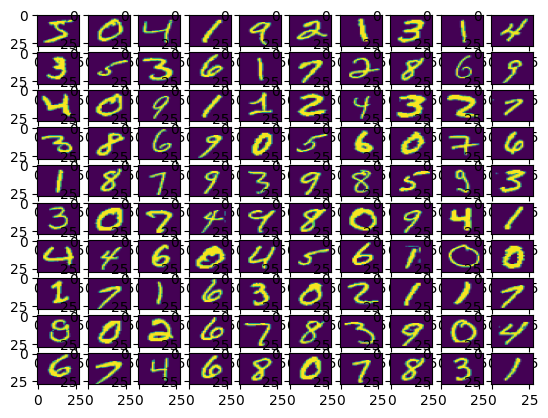

In [5]:
fig, ax = plt.subplots(10, 10)
k = 0
for i in range(10):
    for j in range(10):
        ax[i][j].imshow(x_train[k].reshape(28, 28), aspect='auto')
        k += 1
plt.show()

#### 4. Building the neural network model:
- Here we build a Sequential neural network model.
- The model consist of :
  1. Flatten Layer: Reshapes 2D input (28x28) into a 1D array of 784 elements.
  2. Dense Layer: Fully connected layers with 256 and 128 neurons, both using the relu-activation function.
  3. Output layer: The final layer with 10 neurons representing the 10 classes of digits (0-9) with sigmoid activation.

In [8]:
model = Sequential([ 
    Flatten(input_shape=(28, 28)),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(10, activation='sigmoid'),
])


#### 5. Compile the Model:
- Once the model is defined we compile it by specfying:
  1. Optimizer: Adam for efficent weight updates.
  2. Loss Function: Sparse categorical cross entropy, which is suitable for multi-class classification.
  3. Metrics: Accuracy to evaluate model performance.

In [13]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

#### 6. Training the Model:
- We train the model on training data using 10 epochs and a batch size of 2000.
- We also use 20% of the training data for visualization to monitor the model's performance on unseen data during training.

In [14]:
mod = model.fit(x_train, y_train, epochs=10, batch_size=2000, validation_split=0.2)
print(mod)

Epoch 1/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.4756 - loss: 16.1027 - val_accuracy: 0.6177 - val_loss: 3.4208
Epoch 2/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.6193 - loss: 2.5700 - val_accuracy: 0.6507 - val_loss: 1.8741
Epoch 3/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.6743 - loss: 1.4609 - val_accuracy: 0.7013 - val_loss: 1.4036
Epoch 4/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.7045 - loss: 0.9963 - val_accuracy: 0.6917 - val_loss: 1.1908
Epoch 5/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.7093 - loss: 0.7230 - val_accuracy: 0.7174 - val_loss: 1.0954
Epoch 6/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.7336 - loss: 0.5381 - val_accuracy: 0.7154 - val_loss: 0.9963
Epoch 7/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.7390 - loss: 0.4025 - val_accuracy: 0.7426 - val_loss: 0.9411
Epoch 8/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.7462 - loss: 0.3041 - val_accuracy: 0.7542 - 

#### 7. Evaluating the Model:
- After training we evaluate the model on the test dataset to determine its performance.
  

In [15]:
results = model.evaluate(x_test, y_test, verbose=0)
print('Test loss, Test accuracy:', results)

Test loss, Test accuracy: [0.84816575050354, 0.7436000108718872]


#### 8. Visualizing Training and Validation Loss VS Accuracy:


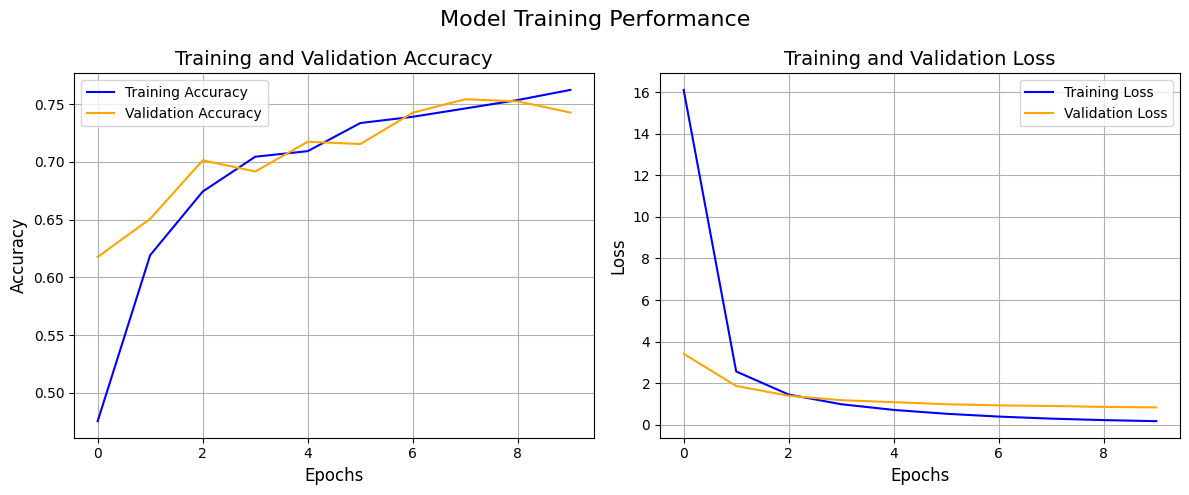

In [16]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(mod.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(mod.history['val_accuracy'],
         label='Validation Accuracy', color='orange')
plt.title('Training and Validation Accuracy', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(mod.history['loss'], label='Training Loss', color='blue')
plt.plot(mod.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Training and Validation Loss', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.grid(True)

plt.suptitle("Model Training Performance", fontsize=16)
plt.tight_layout()
plt.show()